# Performance Comparison Summary

## Load data
Data is stored in `outputs/<algorithm>/<problem>/results.json`

In [278]:

# Load data from output dir
from pathlib import Path
import json

current_dir = Path().resolve()
project_root = current_dir.parent

problems = ('tsp_constructive', 'tsp_aco', 'tsp_pomo', 'tsp_lehd', 
            'cvrp_aco', 'cvrp_pomo', 'cvrp_lehd', 
            'bpp_online', 'bpp_offline_aco',
            'dpp_ga',
            'mkp_aco',
            'op_aco')
algorithms = ('funsearch', 'ael', 'eoh', 'reevo' , 'oragent')

# Problem titles for each subplot
problem_titles = {
    'tsp_constructive': 'TSP_CONSTRUCTIVE (obj type: min)',
    'tsp_aco': 'TSP_ACO (obj type: min)',
    'tsp_pomo': 'TSP_POMO (obj type: min)',
    'tsp_lehd': 'TSP_LEHD (obj type: min)',
    'cvrp_aco': 'CVRP_ACO (obj type: min)',
    'cvrp_pomo': 'CVRP_POMO (obj type: min)',
    'cvrp_lehd': 'CVRP_LEHD (obj type: min)',
    'bpp_online': 'BPP_ONLINE (obj type: min)',
    'bpp_offline_aco': 'BPP_OFFLINE_ACO (obj type: min)',
    'dpp_ga': 'DPP_GA (obj type: max)',
    'mkp_aco': 'MKP_ACO (obj type: max)',
    'op_aco': 'OP_ACO (obj type: max)'
}


# read results.json and store in `results` dict
results = {}
for problem in problems:
    for alg in algorithms:
        filepath = project_root / "outputs" / alg / problem / "results.json"
        with open(filepath, "r") as fp:
            results[(problem, alg)] = json.load(fp)

for k, v in results.items():
    print(f"=====(problem, algorithm): {k}=====")
    for entry in v:
        print(entry)

=====(problem, algorithm): ('tsp_constructive', 'funsearch')=====
{'iteration': 0, 'total_responses': 0, 'total_function_evals': 1, 'total_valid_responses': 0, 'best_obj_overall': 7.034353925627436, 'metrics': {'20': 4.450265933717864, '50': 7.066327190059413, '100': 9.586468653105033}, 'code_filepath': 'outputs/funsearch/tsp_constructive/details/iter0_response0_solution.py', 'output_filepath': 'outputs/funsearch/tsp_constructive/details/iter0_response0_stdout.txt'}
{'iteration': 1, 'total_responses': 20, 'total_function_evals': 21, 'total_valid_responses': 20, 'best_obj_overall': 7.023371412803197, 'metrics': {'20': 4.4735137526525275, '50': 7.039827986086057, '100': 9.556772499671006}, 'code_filepath': 'outputs/funsearch/tsp_constructive/details/iter1_response16_solution.py', 'output_filepath': 'outputs/funsearch/tsp_constructive/details/iter1_response16_stdout.txt'}
{'iteration': 4, 'total_responses': 26, 'total_function_evals': 27, 'total_valid_responses': 23, 'best_obj_overall': 7

In [279]:
# shared plot settings
from plotlib import color_scheme, font_scheme

y_limits = {
    'tsp_constructive': (6.22, 6.8),
    'tsp_aco': (5.98, 6.12),
    'tsp_pomo': (20.29, 21.5),
    'cvrp_aco': (7.02, 8.5),
    'bpp_offline_aco': (126.4, 131.5),
    'dpp_ga': (12.6, 13.40),
    'mkp_aco': (34.5, 35.90),
    'op_aco': (20, 23.42)
}

## Algorithm core over llm calls

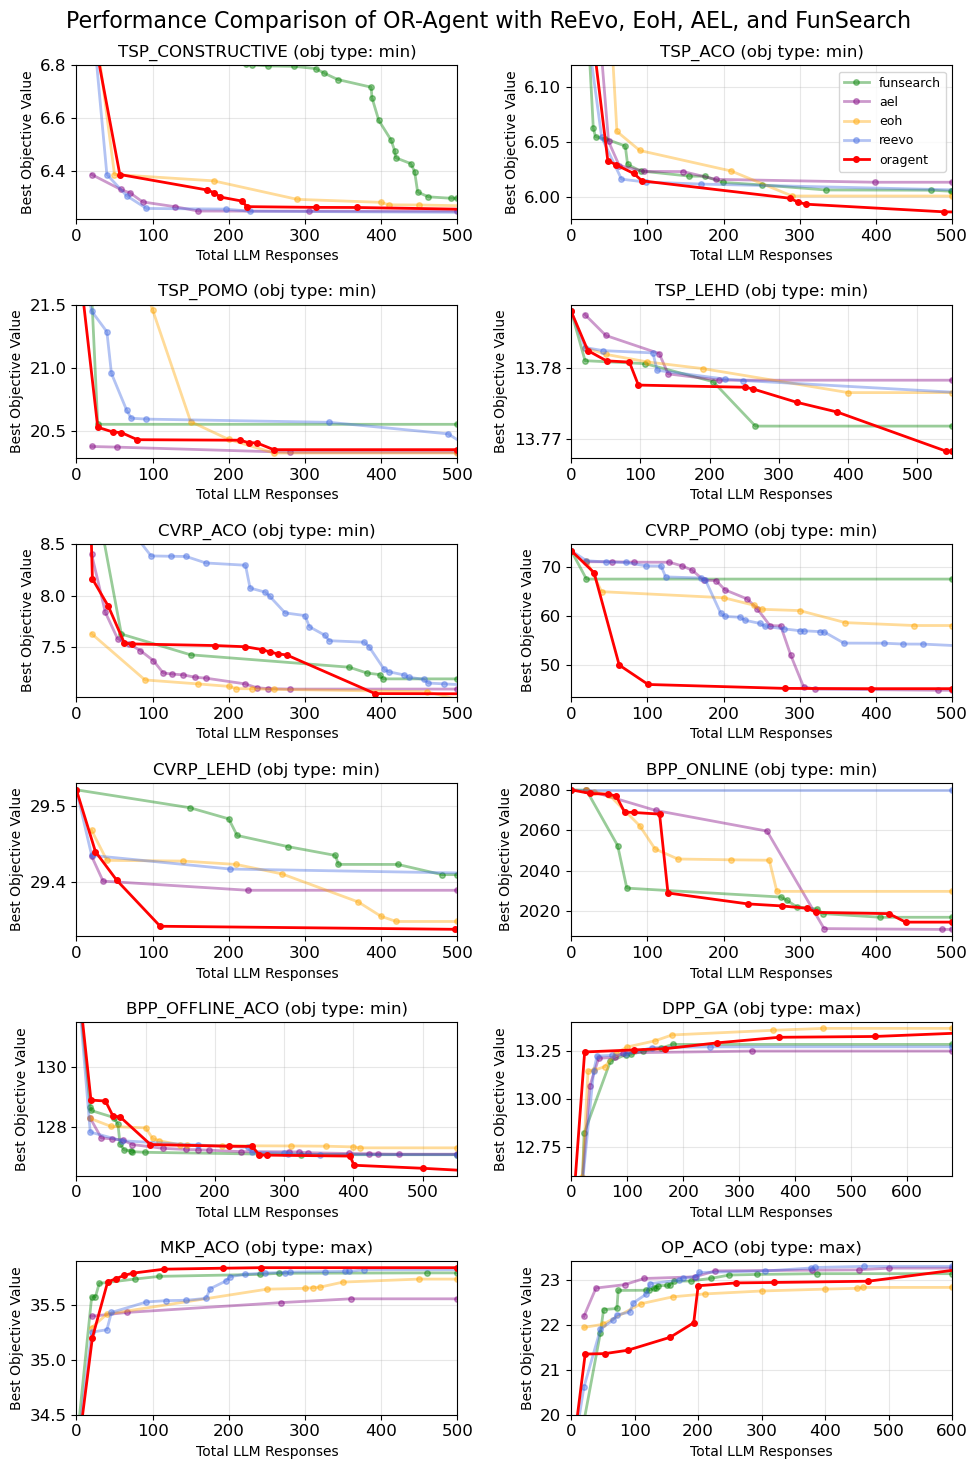

In [280]:
performance_index = 'total_responses'
x_label = 'Total LLM Responses'


# =====x-axis limit based on largest total_responses range=====
min_x = 0
max_x = {
    'tsp_constructive': 500,
    'tsp_aco': 500,
    'tsp_pomo': 500,
    'tsp_lehd': 550,
    'cvrp_aco': 500,
    'cvrp_pomo': 500,
    'cvrp_lehd': 500,
    'bpp_online': 500,
    'bpp_offline_aco': 550,
    'dpp_ga': 680,
    'mkp_aco': 500,
    'op_aco': 600
}


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for problem in problems:
        for alg in algorithms:
            last_entry = deepcopy(results[(problem, alg)][-1])
            if last_entry[performance_index] < max_x[problem]:
                last_entry[performance_index] = max_x[problem]
                results[(problem, alg)].append(last_entry)


# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure
fig, axes = plt.subplots(6, 2, 
                        figsize=(10, 15)
                        )
axes = axes.flatten()

# Plot each algorithm
for idx, problem in enumerate(problems):
    ax = axes[idx]
    
    for alg in algorithms:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[(problem, alg)]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[(problem, alg)]]
        
        # Plot the curve
        alpha = 1.0 if alg == 'oragent' else 0.4
        ax.plot(total_responses, best_obj_overall, marker='o', markersize=4, label=alg, linewidth=2, color=color_scheme[alg], alpha=alpha)

        ax.set_xlim(min_x, max_x[problem])
        
        if problem in y_limits:
            ax.set_ylim(y_limits[problem])
        
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Best Objective Value', fontsize=10)
        ax.set_title(f'{problem_titles[problem]}', fontsize=12)
        ax.grid(True, alpha=0.3)

    # Add legend only to first subplot
    if idx == 1:
        ax.legend(fontsize=9)


fig.suptitle('Performance Comparison of OR-Agent with ReEvo, EoH, AEL, and FunSearch', fontsize=16, y=0.98)

# Adjust layout
plt.tight_layout()
plt.savefig('performance_comparison_llm_responses.png', dpi=300, bbox_inches='tight')
plt.show()

## Algorithm score over evaluations

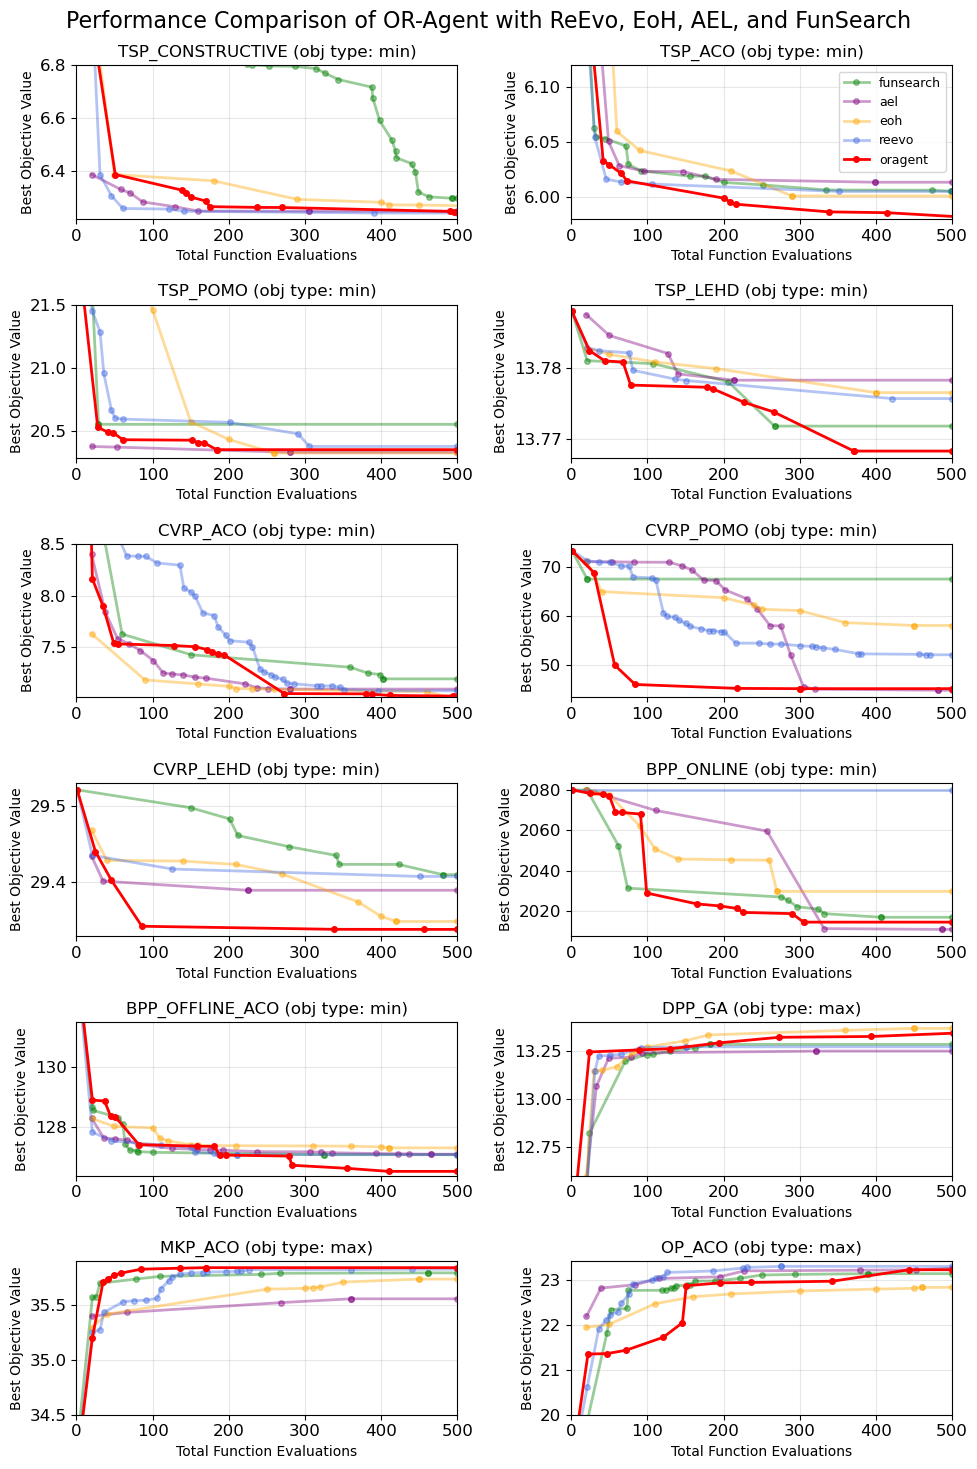

In [281]:
performance_index = 'total_function_evals'  # TODO: change
x_label = 'Total Function Evaluations'  # TODO: change


# =====x-axis limit based on largest total_responses range=====
min_x = 0
max_x = {
    'tsp_constructive': 500,
    'tsp_aco': 500,
    'tsp_pomo': 500,
    'tsp_lehd': 500,
    'cvrp_aco': 500,
    'cvrp_pomo': 500,
    'cvrp_lehd': 500,
    'bpp_online': 500,
    'bpp_offline_aco': 500,
    'dpp_ga': 500,
    'mkp_aco': 500,
    'op_aco': 500
}


# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for problem in problems:
        for alg in algorithms:
            last_entry = deepcopy(results[(problem, alg)][-1])
            if last_entry[performance_index] < max_x[problem]:
                last_entry[performance_index] = max_x[problem]
                results[(problem, alg)].append(last_entry)


# =====Plot=====
import matplotlib.pyplot as plt

plt.rcParams.update(font_scheme)

# Create figure
fig, axes = plt.subplots(6, 2, 
                        figsize=(10, 15)
                        )
axes = axes.flatten()


# Plot each algorithm
for idx, problem in enumerate(problems):
    ax = axes[idx]
    
    for alg in algorithms:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[(problem, alg)]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[(problem, alg)]]
        
        # Plot the curve
        alpha = 1.0 if alg == 'oragent' else 0.4
        ax.plot(total_responses, best_obj_overall, marker='o', markersize=4, label=alg, linewidth=2, color=color_scheme[alg], alpha=alpha)

        ax.set_xlim(min_x, max_x[problem])
        
        # Optional: set y-axis limits
        if problem in y_limits:
            ax.set_ylim(y_limits[problem])
        
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Best Objective Value', fontsize=10)
        ax.set_title(f'{problem_titles[problem]}', fontsize=12)
        ax.grid(True, alpha=0.3)

    # Add legend only to first subplot
    if idx == 1:
        ax.legend(fontsize=9)


fig.suptitle('Performance Comparison of OR-Agent with ReEvo, EoH, AEL, and FunSearch', fontsize=16, y=0.98)

# Adjust layout
plt.tight_layout()
plt.savefig('performance_comparison_function_evals.png', dpi=300, bbox_inches='tight')
plt.show()

## Statistics

`results` is a dictionary with keys: `(problem, algorithm)`.
There are 12 problems and 5 algorithms:
problems = ('tsp_constructive', 'tsp_aco', 'tsp_pomo', 'tsp_lehd', 
            'cvrp_aco', 'cvrp_pomo', 'cvrp_lehd', 
            'bpp_online', 'bpp_offline_aco',
            'dpp_ga',
            'mkp_aco',
            'op_aco')
algorithms = ('reevo', 'eoh', 'ael', 'funsearch', 'oragent')


`results[(problem, algorithm)]` is a list of dictionaries, appended during algorithm running. results[(problem, algorithm)][-1] is the last entry of the results.

`results[(problem, algorithm)]` example:
```
{
    'iteration': 68, 
    'total_responses': 882, 
    'total_function_evals': 510, 
    'total_valid_responses': 840, 
    'best_obj_overall': 6.569197520849483, 
    'metrics': 
        {
            '20': 4.187638413495045, 
            '50': 6.500550290687575, 
            '100': 9.01940385836583
        }, 
    'code_filepath': 'outputs/reevo/tsp_constructive/reevo3/details/iter68_response9_solution.py', 
    'output_filepath': 'outputs/reevo/tsp_constructive/reevo3/details/iter68_response9_stdout.txt'
}
```

`obj_type` tells us whether the problem is minimization or maximization.
```
obj_type = {
    'tsp_constructive': 'min',
    'tsp_aco': 'min',
    'tsp_pomo': 'min',
    'tsp_lehd': 'min',
    'cvrp_aco': 'min',
    'cvrp_pomo': 'min',
    'cvrp_lehd': 'min',
    'bpp_online': 'min',
    'bpp_offline_aco': 'min',
    'dpp_ga': 'max',
    'mkp_aco': 'max',
    'op_aco': 'max'
}
```


Normalized score is used to compare the performance of different algorithms.
`normalized_scores` is a dict with keys: `(problem, algorithm)`; it stores the normalized score for a algorithm on a problem.
For a given problem, we need compute normalized score for all five algorithms. 

First, we find the best and worst score (`overall_best`, `overall_worst`) for the problem among all five algorithms. 
Namely, we compare the five values of `results[(problem, algorithm)][-1]['best_obj_overall']` (`algorithm` is one of `algorithms`);

Then, for each algorithm, we compute normalized score by:
```
normalized_score = |algorithm_best_obj - overall_worst_obj| / |overall_best_obj - overall_worst_obj|
```
where `algorithm_best_obj` is the best score of the algorithm for the given problem, namely the last entry in `results[(problem, algorithm)]`;
The normalized is score is between 0 and 1, where 0 means the algorithm is the worst and 1 means the algorithm is the best.

Then store the normalized score in `normalized_scores[(problem, algorithm)]`.

After we have computed normalized scores for all problems and algorithms, we can compute the average normalized score for each algorithm and store in `avg_normalized_scores`. `avg_normalized_scores[algorithm]` is the average normalized score the algorithm.


In [282]:
## Performance computation code
obj_type = {
    'tsp_constructive': 'min',
    'tsp_aco': 'min',
    'tsp_pomo': 'min',
    'tsp_lehd': 'min',
    'cvrp_aco': 'min',
    'cvrp_pomo': 'min',
    'cvrp_lehd': 'min',
    'bpp_online': 'min',
    'bpp_offline_aco': 'min',
    'dpp_ga': 'max',
    'mkp_aco': 'max',
    'op_aco': 'max'
}

# Compute normalized scores
normalized_scores = {}
avg_normalized_scores = {}

for problem in problems:
    # Get final scores for all algorithms
    final_scores = {}
    for alg in algorithms:
        final_scores[alg] = results[(problem, alg)][-1]['best_obj_overall']

    # Find best and worst based on objective type
    if obj_type[problem] == 'min':
        overall_best = min(final_scores.values())
        overall_worst = max(final_scores.values())
    else:  # maximization
        overall_best = max(final_scores.values())
        overall_worst = min(final_scores.values())

    # Handle edge case where all algorithms perform identically
    if abs(overall_best - overall_worst) < 1e-10:
        # All algorithms tied - assign equal scores
        for alg in algorithms:
            normalized_scores[(problem, alg)] = 0.5
        continue

    # Compute normalized scores
    for alg in algorithms:
        algorithm_best = final_scores[alg]

        if obj_type[problem] == 'min':
            # For minimization: better = lower values
            normalized_score = (overall_worst - algorithm_best) / (overall_worst - overall_best)
        else:
            # For maximization: better = higher values
            normalized_score = (algorithm_best - overall_worst) / (overall_best - overall_worst)

        normalized_scores[(problem, alg)] = normalized_score

# Compute average normalized scores per algorithm
for alg in algorithms:
    scores = [normalized_scores[(problem, alg)] for problem in problems]
    avg_normalized_scores[alg] = sum(scores) / len(scores)

# Display results
print("Normalized Scores (0=worst, 1=best):")
print("-" * 80)
print(f"{'Problem':<25} {'FunSearch':<8} {'AEL':<8} {'EoH':<8} {'ReEvo':<10} {'OR-Agent':<10}")
print("-" * 80)

for problem in problems:
    row = [f"{problem:<25}"]
    for alg in algorithms:
        score = normalized_scores[(problem, alg)]
        row.append(f"{score:<8.3f}")
    print(" ".join(row))

print("-" * 80)
print("\nAverage Normalized Scores:")
print("-" * 40)
for alg in algorithms:
    print(f"{alg:<12}: {avg_normalized_scores[alg]:.3f}")
print("-" * 40)

# Additional analysis: ranking per problem
print("\nAlgorithm Rankings per Problem:")
print("-" * 60)
for problem in problems:
    # Get scores for this problem
    problem_scores = {alg: normalized_scores[(problem, alg)] for alg in algorithms}
    # Sort by score (descending)
    ranked = sorted(problem_scores.items(), key=lambda x: x[1], reverse=True)

    print(f"{problem:<18}: ", end="")
    for i, (alg, score) in enumerate(ranked):
        if i > 0:
            print(", ", end="")
        print(f"{alg} ({score:.3f})", end="")
    print()

Normalized Scores (0=worst, 1=best):
--------------------------------------------------------------------------------
Problem                   FunSearch AEL      EoH      ReEvo      OR-Agent  
--------------------------------------------------------------------------------
tsp_constructive          0.000    0.878    0.788    1.000    0.959   
tsp_aco                   0.252    0.000    0.386    0.258    1.000   
tsp_pomo                  0.000    0.975    1.000    0.771    0.884   
tsp_lehd                  0.648    0.000    0.175    0.259    1.000   
cvrp_aco                  0.000    0.403    1.000    0.471    0.680   
cvrp_pomo                 0.000    1.000    0.418    0.681    0.986   
cvrp_lehd                 0.000    0.285    0.855    0.033    1.000   
bpp_online                0.913    1.000    0.728    0.000    0.948   
bpp_offline_aco           0.290    0.270    0.000    0.290    1.000   
dpp_ga                    0.294    0.000    1.000    0.190    0.787   
mkp_aco        